<a href="https://colab.research.google.com/github/kellsieglaring/AI-Resume-Screening-Interview-Scheduler/blob/main/AI_Resume_Screening_%26_Interview_Scheduler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import pickle

## Load Dataset

In [65]:
df = pd.read_csv("/content/archive.zip")

df.head()

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05


# Understand Dataset

In [66]:
print(df.shape)

(9000, 20)


In [67]:
print(df.columns)

Index(['student_id', 'cgpa', 'branch', 'college_tier', 'python_skill',
       'dsa_skill', 'ml_skill', 'web_dev_skill', 'coding_score',
       'communication_score', 'aptitude_score', 'internships', 'projects',
       'backlogs', 'resume_score', 'skill_score', 'placed', 'company_type',
       'job_role', 'salary_lpa'],
      dtype='object')


In [68]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   object 
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   object 
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill_score          9000 non-null   i

In [69]:
print(df.describe())

              cgpa  college_tier  python_skill    dsa_skill     ml_skill  \
count  9000.000000   9000.000000   9000.000000  9000.000000  9000.000000   
mean      7.507213      2.011778      0.650111     0.555556     0.299778   
std       1.446496      0.818224      0.476961     0.496932     0.458186   
min       5.000000      1.000000      0.000000     0.000000     0.000000   
25%       6.257500      1.000000      0.000000     0.000000     0.000000   
50%       7.500000      2.000000      1.000000     1.000000     0.000000   
75%       8.750000      3.000000      1.000000     1.000000     1.000000   
max      10.000000      3.000000      1.000000     1.000000     1.000000   

       web_dev_skill  coding_score  communication_score  aptitude_score  \
count    9000.000000   9000.000000          9000.000000     9000.000000   
mean        0.393444     49.783567             6.991267       70.125711   
std         0.488541     28.891340             1.717548       17.475032   
min         0.0

# Check Missing Values

In [70]:
df.isnull().sum()

,0
student_id,0
cgpa,0
branch,0
college_tier,0
python_skill,0
dsa_skill,0
ml_skill,0
web_dev_skill,0
coding_score,0
communication_score,0


# Remove Duplicates

In [71]:
df.drop_duplicates(inplace=True)

# Fill Missing Values

For Numerical Columns

In [72]:
df.fillna(df.median(numeric_only=True), inplace=True)

For Categorical Columns

In [73]:
for col in df.select_dtypes(include="object"):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_513/2308743177.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


# Encode Categorical Data

In [74]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = encoder.fit_transform(df[col])

# Exploratory Data Analysis

Histogram

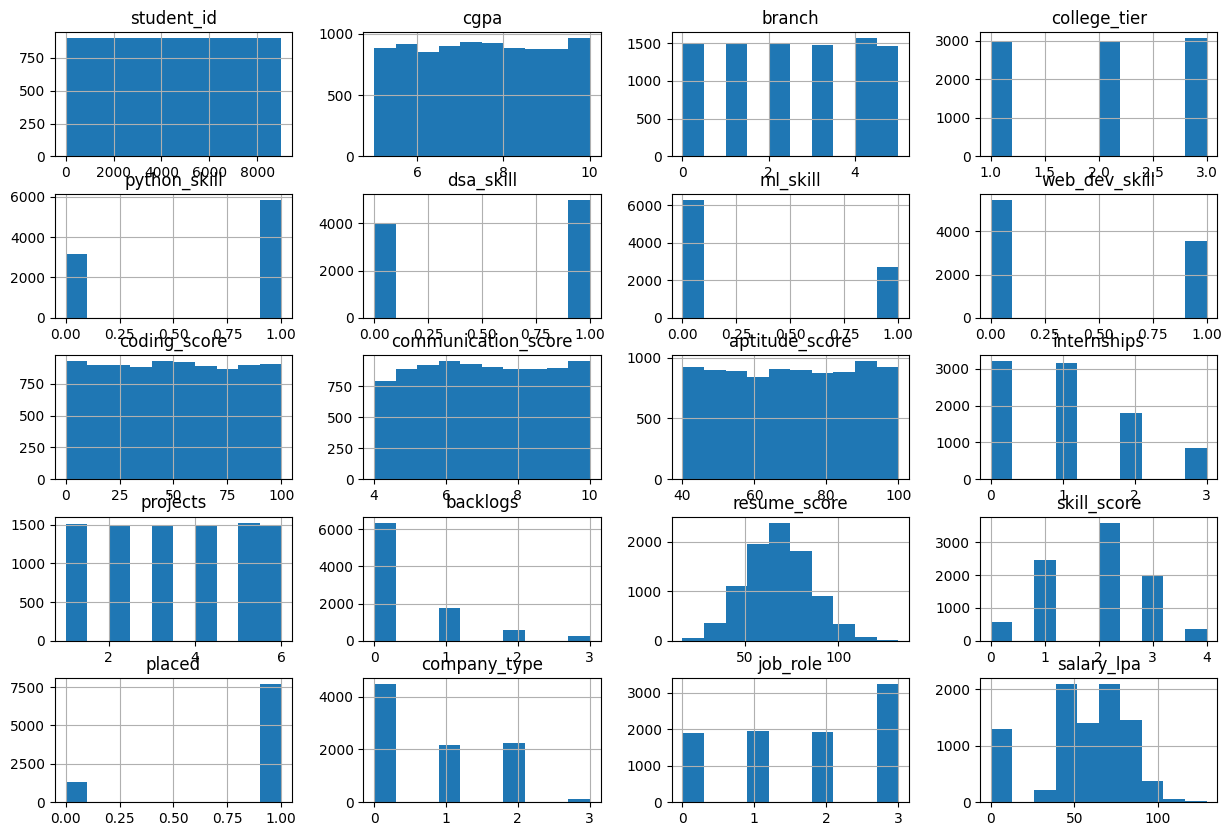

In [75]:
df.hist(figsize=(15,10))
plt.show()

Correlation

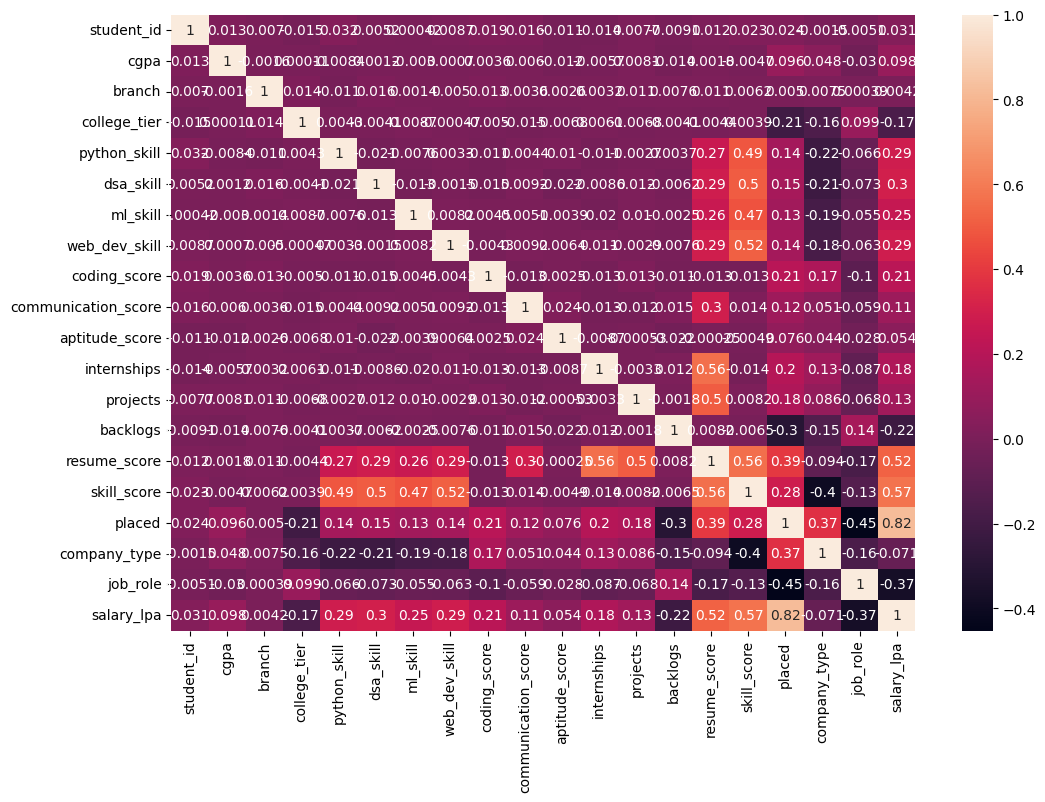

In [76]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

# Select Features

In [77]:
X = df.drop(columns=[
    "placed",
    "salary_lpa",
    "student_id",
    "Prediction",
    "Score",
    "Ranking Score"
], errors="ignore")

y = df["placed"]

print(X.head())
print(y.head())

   cgpa  branch  college_tier  python_skill  dsa_skill  ml_skill  \
0  6.87       1             1             1          1         0   
1  6.52       1             2             1          0         0   
2  5.33       4             1             1          1         1   
3  6.04       1             3             1          0         1   
4  6.78       5             2             0          1         0   

   web_dev_skill  coding_score  communication_score  aptitude_score  \
0              0          15.6                  4.3            92.0   
1              1          13.9                  5.8            62.0   
2              0           9.8                  8.1            66.4   
3              0          39.5                  9.6            83.6   
4              1           7.5                  9.9            86.3   

   internships  projects  backlogs  resume_score  skill_score  company_type  \
0            1         3         0          62.6            2             0   
1     

# Split Dataset

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (7200, 17)
Testing Data: (1800, 17)


# Train Model

In [79]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


# Prediction

In [80]:
y_pred=model.predict(X_test)

# Accuracy

In [81]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 98.28 %


# Classification Report

In [82]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       288
           1       0.99      0.99      0.99      1512

    accuracy                           0.98      1800
   macro avg       0.96      0.98      0.97      1800
weighted avg       0.98      0.98      0.98      1800



# Confusion Matrix

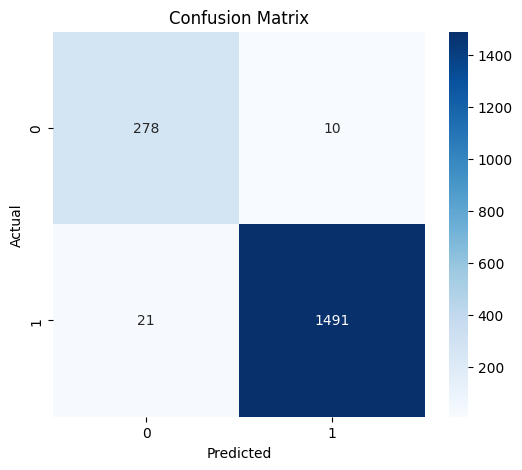

In [83]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ROC Curve

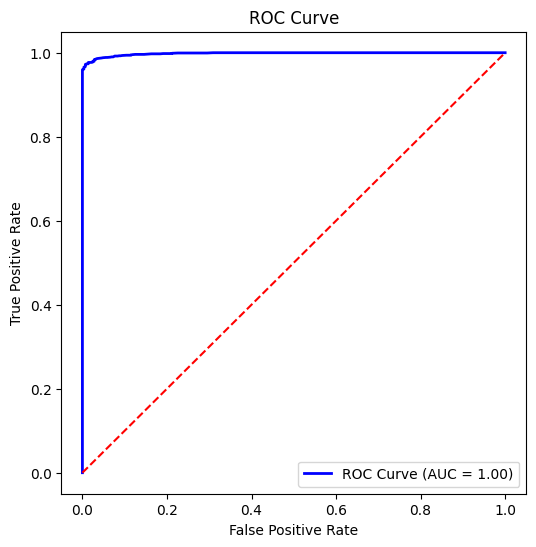

AUC Score: 0.9980422821134627


In [84]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability of positive class
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

print("AUC Score:", roc_auc)

# Save Model

In [85]:
import joblib

joblib.dump(model,"resume_screening_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


# Candidate Ranking

In [86]:
df["Prediction"] = model.predict(X)

df["Score"] = model.predict_proba(X)[:,1]

df["Ranking Score"] = (
      df["cgpa"]*10
    + df["resume_score"]
    + df["coding_score"]
    + df["communication_score"]
    + df["aptitude_score"]
)

shortlisted = df[df["Prediction"]==1]

shortlisted = shortlisted.sort_values(
    by="Ranking Score",
    ascending=False
)

shortlisted.head(20)

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,...,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa,Prediction,Score,Ranking Score
4883,4316,9.68,3,1,0,1,1,0,80.2,8.8,...,0,111.4,2,1,1,2,70.62,1,1.0,395.1
5565,5074,9.54,3,3,1,0,1,1,91.5,8.6,...,0,101.2,3,1,1,0,56.33,1,1.0,387.0
4893,4327,7.98,5,2,1,1,1,1,95.6,9.7,...,0,114.9,4,1,1,1,59.15,1,1.0,386.7
3236,2487,9.52,3,3,1,1,1,1,82.8,8.6,...,0,105.8,4,1,0,0,99.27,1,1.0,385.0
5626,5142,9.96,5,1,1,1,1,0,78.7,7.6,...,0,99.8,3,1,3,3,124.13,1,1.0,383.4
1441,493,8.05,3,1,1,1,1,1,98.1,9.9,...,0,108.3,4,1,3,0,129.43,1,1.0,383.1
8613,8461,9.84,0,3,1,1,1,1,94.9,9.3,...,2,99.4,4,1,0,0,82.47,1,1.0,380.4
8504,8340,9.33,5,2,1,1,0,0,87.4,10.0,...,0,97.9,2,1,0,3,78.05,1,1.0,378.6
5929,5478,7.40,2,3,1,0,1,0,85.6,9.1,...,1,111.0,2,1,0,2,95.72,1,1.0,378.5
3913,3239,8.51,0,1,1,0,1,0,99.6,9.2,...,0,86.7,2,1,0,1,84.29,1,1.0,378.0


# Feature Importance

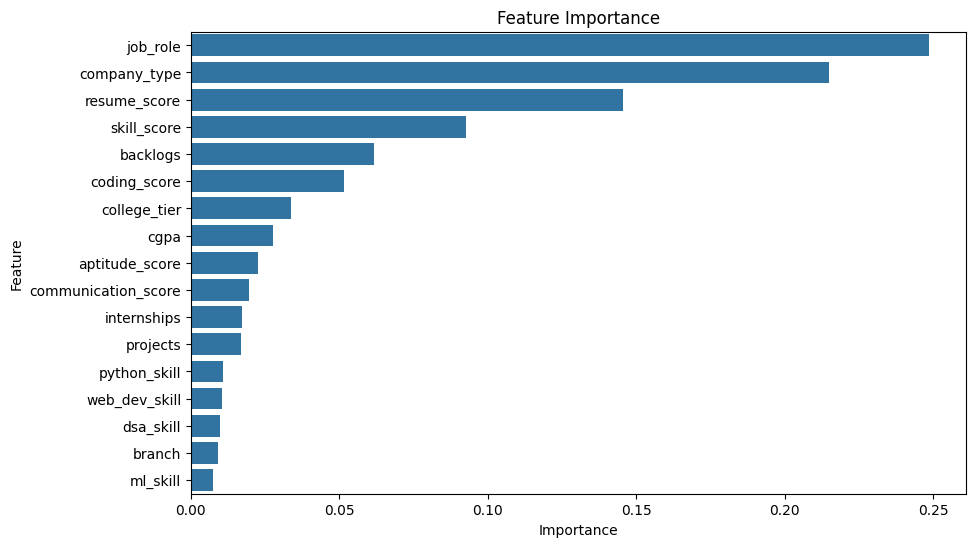

In [87]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

# Export Shortlisted Candidates

In [88]:
shortlisted = top_candidates[top_candidates["Prediction"] == 1]

shortlisted.to_csv(
    "Shortlisted_Candidates.csv",
    index=False
)

print("Shortlisted candidates exported successfully!")

Shortlisted candidates exported successfully!


# Test New Candidate

In [89]:
new_candidate = pd.DataFrame({
    "cgpa":[8.5],
    "branch":[1],
    "college_tier":[2],
    "python_skill":[85],
    "dsa_skill":[80],
    "ml_skill":[75],
    "web_dev_skill":[70],
    "coding_score":[88],
    "communication_score":[90],
    "aptitude_score":[86],
    "internships":[2],
    "projects":[4],
    "backlogs":[0],
    "resume_score":[90],
    "skill_score":[88],
    "company_type":[1],
    "job_role":[2]
})

prediction = model.predict(new_candidate)

if prediction[0] == 1:
    print("Candidate is SHORTLISTED")
else:
    print("Candidate is NOT SHORTLISTED")

Candidate is SHORTLISTED


# Final Result Analysis

In [90]:
print("Total Candidates :", len(df))
print("Shortlisted :", len(shortlisted))
print("Rejected :", len(df)-len(shortlisted))

print("\nTop 10 Candidates")

shortlisted.head(10)

Total Candidates : 9000
Shortlisted : 7702
Rejected : 1298

Top 10 Candidates


,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,...,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa,Prediction,Score,Ranking Score
8839,8711,9.13,3,2,1,1,1,1,99.8,9.2,...,0,118.0,4,1,1,2,64.56,1,1.0,358.3
7219,6912,9.96,3,3,1,1,1,1,94.3,6.2,...,0,115.5,4,1,0,2,76.45,1,1.0,355.6
7295,6996,9.54,3,2,1,1,1,1,89.7,9.2,...,0,121.3,4,1,1,3,56.59,1,1.0,355.6
8613,8461,9.84,0,3,1,1,1,1,94.9,9.3,...,2,99.4,4,1,0,0,82.47,1,1.0,342.0
5742,5271,9.78,1,2,1,1,1,0,97.7,9.4,...,2,105.2,3,1,1,1,63.03,1,1.0,340.1
4893,4327,7.98,5,2,1,1,1,1,95.6,9.7,...,0,114.9,4,1,1,1,59.15,1,1.0,340.0
8637,8487,9.84,2,2,1,1,1,1,96.6,9.3,...,0,93.5,4,1,0,2,84.49,1,1.0,337.8
1441,493,8.05,3,1,1,1,1,1,98.1,9.9,...,0,108.3,4,1,3,0,129.43,1,1.0,336.8
4936,4375,9.63,1,2,1,0,1,1,91.3,6.6,...,1,108.4,3,1,0,2,75.45,1,1.0,332.6
3236,2487,9.52,3,3,1,1,1,1,82.8,8.6,...,0,105.8,4,1,0,0,99.27,1,1.0,332.4


# Conclusion



- Successfully loaded and preprocessed the dataset.
- Removed missing values and duplicate records.
- Encoded categorical features.
- Trained a Random Forest model to predict candidate placement.
- Ranked candidates based on suitability.
- Exported shortlisted candidates.
- The system can be integrated with UiPath RPA to automate resume screening and interview scheduling.

# Future Scope


- Extract information directly from PDF resumes using OCR.
- Use NLP to identify technical skills from resumes.
- Integrate the system with UiPath for end-to-end automation.
- Automatically schedule interviews using Outlook or Gmail.
- Build an HR dashboard using Streamlit.
- Deploy the model as a web application using Flask.

# RPA Workflow


1. Receive resumes through email.
2. UiPath downloads resume attachments automatically.
3. OCR extracts resume details.
4. Python ML model predicts candidate suitability.
5. Candidates are ranked based on the prediction score.
6. Shortlisted candidates are saved to an Excel/CSV file.
7. UiPath updates the HR database.
8. Interview invitation emails are sent automatically.